# Cardiomegaly Classifier — Training Notebook

This notebook is intentionally minimal. All logic lives in `src/`.

| File | Responsibility |
|------|----------------|
| `src/config.py` | `Config` dataclass + global `CFG` |
| `src/utils.py` | `set_seed`, `free_device_cache` |
| `src/data.py` | `load_labels`, `split_dataframe`, `estimate_gray_mean_std` |
| `src/dataset.py` | `CardiomegalyDataset`, `SubmissionDataset` |
| `src/transforms.py` | `make_transforms`, `make_tta_transforms` |
| `src/model.py` | `CardiomegalyModel`, `build_model`, freeze helpers |
| `src/train.py` | `train_model`, `run_epoch_tta`, `optuna_search`, `save_results` |

## 1 · Environment Setup (Colab + Git)

**Google Colab users:** just run all cells top to bottom — git clone, dependencies and OneDrive sync are all handled automatically.  
**Local users:** the Colab-specific blocks are skipped automatically.

In [ ]:
import os
import sys
import subprocess

# ── Detect Google Colab ──────────────────────────────────────────────────────
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # ── 1. Clone or pull the repository ─────────────────────────────────────
    REPO_URL    = "https://github.com/jcvilar19/med-image-clarity.git" 
    REPO_FOLDER = "/content/med-image-clarity"

    if not os.path.exists(REPO_FOLDER):
        print("Cloning repository...")
        subprocess.run(["git", "clone", REPO_URL, REPO_FOLDER], check=True)
    else:
        print("Pulling latest changes...")
        subprocess.run(["git", "-C", REPO_FOLDER, "pull", "origin", "main"], check=True)

    # ── 2. Change working directory to notebooks/ ────────────────────────────
    os.chdir(f"{REPO_FOLDER}/model_training/notebooks")
    print(f"Working directory: {os.getcwd()}")

    # ── 3. Install Python dependencies ───────────────────────────────────────
    print("Installing dependencies...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", "../requirements.txt"],
        check=True,
    )
    print("✓ Dependencies installed")

# ── Add src/ to Python path (works for both Colab and local) ────────────────
sys.path.insert(0, os.path.abspath(".."))

from src.config import CFG
from src.utils import set_seed

set_seed(CFG.seed)
print(f"\nDevice  : {CFG.device}")
print(f"img_size: {CFG.img_size}")
print(f"Results : {CFG.output_dir}")

Device : mps
img_size: 300
Results : results


### 1.1 · Google Drive Setup

Results are saved to a **shared Google Drive folder** after training so every team member can compare all runs in one place.

**One-time setup per person:**
1. Ask the team lead to share the Google Drive folder with your Google account (edit access)
2. Go to [drive.google.com](https://drive.google.com) → "Shared with me" → right-click the folder → **"Add shortcut to My Drive"**
3. Note the path you placed it at (e.g. `cardiomegaly-results`)
4. Update `GDRIVE_RESULTS_FOLDER` in the cell below

**Every session:** Google Drive is mounted automatically when you run this cell.

In [ ]:
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    print("Google Drive mounted ✓")

    # ── Path to the shared Google Drive folder ───────────────────────────────
    # Update this to match where you placed the shortcut in your Google Drive.
    GDRIVE_RESULTS_FOLDER = "/content/drive/MyDrive/cardiomegaly-results"  # ← UPDATE THIS

    os.makedirs(GDRIVE_RESULTS_FOLDER, exist_ok=True)
    print(f"Shared results folder: {GDRIVE_RESULTS_FOLDER}")
else:
    GDRIVE_RESULTS_FOLDER = None
    print("Running locally — Google Drive sync will be skipped")

## 2 · Data Loading & Splitting

In [2]:
from src.data import load_labels, split_dataframe, estimate_gray_mean_std

full_df                   = load_labels(CFG.csv_path, CFG.image_dir)
train_df, val_df, test_df = split_dataframe(full_df)
train_mean, train_std     = estimate_gray_mean_std(train_df, CFG.stats_sample_size)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
print(f"Grayscale mean: {train_mean:.6f}  std: {train_std:.6f}")

Loaded 1578 rows
label
No Finding      858
Cardiomegaly    720
Name: count, dtype: int64
Age range: 3–92  |  Sex: {'M': 796, 'F': 782}
Train: 1104  Val: 237  Test: 237
Grayscale mean: 0.536122  std: 0.253286


## 3 · Datasets & DataLoaders

In [3]:
from torch.utils.data import DataLoader
from src.dataset import CardiomegalyDataset
from src.transforms import make_transforms

train_tf, eval_tf = make_transforms(train_mean, train_std)

train_ds = CardiomegalyDataset(train_df, transform=train_tf)
val_ds   = CardiomegalyDataset(val_df,   transform=eval_tf)
test_ds  = CardiomegalyDataset(test_df,  transform=eval_tf)

_kw = dict(batch_size=CFG.batch_size, num_workers=CFG.num_workers, pin_memory=False)
train_loader = DataLoader(train_ds, shuffle=True,  **_kw)
val_loader   = DataLoader(val_ds,   shuffle=False, **_kw)
test_loader  = DataLoader(test_ds,  shuffle=False, **_kw)

print(f"Batches — train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}")

Batches — train: 35  val: 8  test: 8


## 4 · Hyperparameter Search (optional)

Skip this section to train with the default `CFG` values.
Run it to let Optuna find better hyperparameters automatically.

In [4]:
# from src.train import optuna_search, apply_best_params

# N_TRIALS = 20  # increase for more thorough search (~1-2 min per trial on MPS)

# study = optuna_search(train_ds, val_ds, train_df, n_trials=N_TRIALS)
# train_loader, val_loader, test_loader, BEST_N_BLOCKS = apply_best_params(
#     study, train_ds, val_ds, test_ds
# )

## 5 · Train Model

In [5]:
from src.model import build_model
from src.train import train_model

n_blocks = 7
# BEST_N_BLOCKS if "BEST_N_BLOCKS" in vars() else 7

model   = build_model(CFG.dropout).to(CFG.device)
model, history = train_model(
    model, train_loader, val_loader, train_df, n_blocks=n_blocks
)

pos_weight: 1.1905  (neg=600, pos=504)
Training on: mps  |  frozen_epochs: 3
[frozen] epoch  1/3 | train_loss=0.7469 | val_loss=0.7385 | val_auc=0.6670 | val_acc=0.6076
[frozen] epoch  2/3 | train_loss=0.7215 | val_loss=0.7238 | val_auc=0.7086 | val_acc=0.6160
[frozen] epoch  3/3 | train_loss=0.7085 | val_loss=0.7135 | val_auc=0.7272 | val_acc=0.6624

Fine-tuning last 7 EfficientNet blocks
[finetune] epoch  1/15 | train_loss=0.6914 | val_loss=0.6702 | val_auc=0.7623 | val_acc=0.7004
[finetune] epoch  2/15 | train_loss=0.6341 | val_loss=0.6321 | val_auc=0.7878 | val_acc=0.7257
[finetune] epoch  3/15 | train_loss=0.5822 | val_loss=0.6000 | val_auc=0.8193 | val_acc=0.7215
[finetune] epoch  4/15 | train_loss=0.5432 | val_loss=0.5663 | val_auc=0.8375 | val_acc=0.7553
[finetune] epoch  5/15 | train_loss=0.5108 | val_loss=0.5284 | val_auc=0.8660 | val_acc=0.7848
[finetune] epoch  6/15 | train_loss=0.4535 | val_loss=0.5003 | val_auc=0.8845 | val_acc=0.7932
[finetune] epoch  7/15 | train_loss=0

## 6 · TTA Evaluation & Threshold Selection

In [6]:
from src.train import run_epoch_tta, find_best_threshold, compute_basic_metrics
from src.transforms import make_tta_transforms

tta_transforms = make_tta_transforms(train_mean, train_std)

val_out  = run_epoch_tta(model, val_df,  tta_transforms)
test_out = run_epoch_tta(model, test_df, tta_transforms)

print(f"Val  AUC (TTA): {val_out['auc']:.4f}")
print(f"Test AUC (TTA): {test_out['auc']:.4f}")

best_threshold, _ = find_best_threshold(val_out["y_true"], val_out["y_prob"], mode="youden")
print(f"\nSelected threshold (Youden): {best_threshold:.4f}")

for name, out in [("Validation", val_out), ("Test", test_out)]:
    m = compute_basic_metrics(out["y_true"], out["y_prob"], best_threshold)
    print(f"\n{name}: AUC={m['auc']:.4f}  Sens={m['sensitivity']:.4f}  Spec={m['specificity']:.4f}")

Val  AUC (TTA): 0.9104
Test AUC (TTA): 0.9032

Selected threshold (Youden): 0.5777

Validation: AUC=0.9104  Sens=0.8241  Spec=0.8450

Test: AUC=0.9032  Sens=0.7870  Spec=0.8682


## 7 · ROC Curves

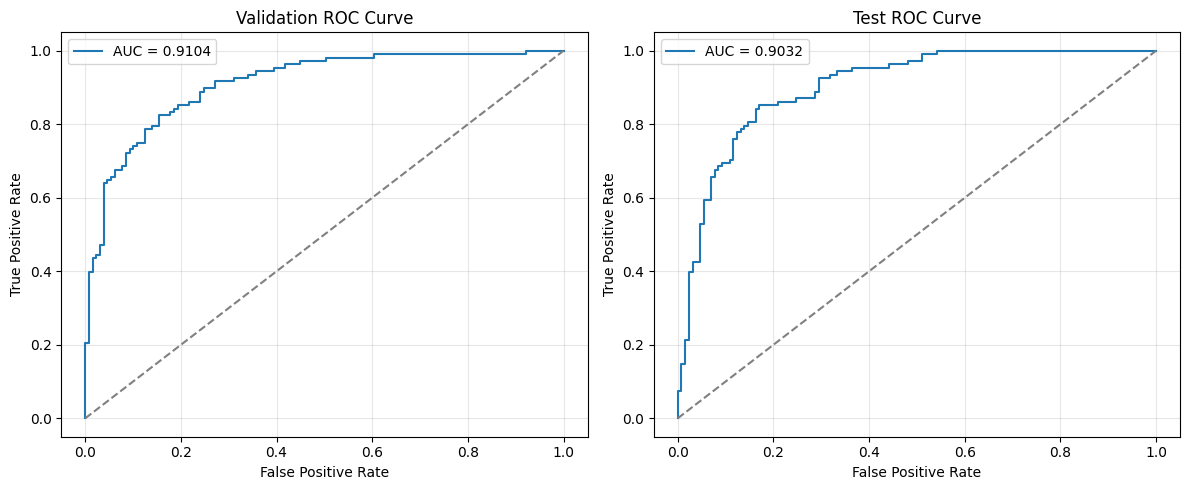

In [7]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, out, title in [(axes[0], val_out, "Validation"), (axes[1], test_out, "Test")]:
    fpr, tpr, _ = roc_curve(out["y_true"], out["y_prob"])
    ax.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.4f}")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{title} ROC Curve")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CFG.output_dir, "roc_curves.png"), dpi=150)
plt.show()

## 8 · Save Results

In [8]:
from src.train import save_results

# Please change your model name here - it will be used to name the model file and the run in the results log
MODEL_NAME = "efficientnet_b3_tabular"

save_results(
    model=model,
    history=history,
    val_out=val_out,
    test_out=test_out,
    best_threshold=best_threshold,
    output_dir=CFG.output_dir,
    model_name=MODEL_NAME,
    n_blocks=n_blocks,
    config=CFG,
)

Results saved → results
Run logged → results_log.csv  (1 total runs)


## 9 · Sync Results to Shared Google Drive

Results are copied to the shared Google Drive folder automatically.  
Every team member's run is merged into the shared `results_log.csv` so you can compare all runs in one place.

In [ ]:
import shutil
import pandas as pd

if IN_COLAB and GDRIVE_RESULTS_FOLDER:
    gdrive_log_path = os.path.join(GDRIVE_RESULTS_FOLDER, "results_log.csv")

    # ── Merge results_log.csv with the shared one ────────────────────────────
    local_log  = pd.read_csv("results_log.csv") if os.path.exists("results_log.csv") else pd.DataFrame()
    remote_log = pd.read_csv(gdrive_log_path)   if os.path.exists(gdrive_log_path)   else pd.DataFrame()

    merged_log = (
        pd.concat([remote_log, local_log], ignore_index=True)
          .drop_duplicates(subset=["run_id"])
    )
    merged_log.to_csv("results_log.csv", index=False)
    merged_log.to_csv(gdrive_log_path, index=False)
    print(f"results_log.csv merged  ({len(merged_log)} total runs)")

    # ── Copy run results folder to Google Drive ──────────────────────────────
    run_dest = os.path.join(GDRIVE_RESULTS_FOLDER, MODEL_NAME)
    shutil.copytree(CFG.output_dir, run_dest, dirs_exist_ok=True)

    print(f"✓ Run artefacts  → {run_dest}")
    print(f"✓ results_log.csv → {gdrive_log_path}")

elif IN_COLAB:
    print("⚠️  Google Drive folder not set. Check GDRIVE_RESULTS_FOLDER in Section 1.1.")
else:
    print(f"Running locally — results are in: {CFG.output_dir}")

## 10 · Submission (optional)

Only needed if unlabelled test images exist at `CFG.submission_test_dir`.

In [9]:
import os, pandas as pd
from src.train import predict_submission_tta

if os.path.isdir(CFG.submission_test_dir):
    submission_out = predict_submission_tta(model, CFG.submission_test_dir, tta_transforms)
    sub_df = pd.DataFrame({
        "image_file": submission_out["names"],
        "prob":       submission_out["y_prob"],
    })
    sub_df["pred"] = (sub_df["prob"] >= best_threshold).astype(int)
    sub_path = os.path.join(CFG.output_dir, "daily_submission.csv")
    sub_df.to_csv(sub_path, index=False)
    print(f"Submission saved → {sub_path}  ({len(sub_df)} rows)")
    display(sub_df.head())
else:
    print(f"No submission directory found at: {CFG.submission_test_dir}")

No submission directory found at: ../../data/test_images
